# 🛠️ Projeto Final: Manutenção Preditiva de Máquinas (AI4I 2020)

- **Disciplina:** Inteligência Artificial e Aprendizagem de Máquina  
- **Curso:** Engenharia de Controle e Automação  
- **IFPB - Campus Cajazeiras**
- **Autores:**
    - Jéssica Layanne Alves Leite
    - Julio Cesar Pereira Rodrigues
    - Joao Claudio de Oliveira Gomes
    - Alexandre Goncalves Matias
- **Data (apresentação):** __/__/____


## 1. Introdução e Objetivos

### 🎯 Problema e Motivação

No contexto da **Indústria 4.0**, prever falhas em equipamentos antes que elas ocorram é fundamental para reduzir paradas não planejadas, custos de manutenção e riscos operacionais. Este projeto desenvolve um sistema de **manutenção preditiva** capaz de classificar, a partir de leituras de sensores, se uma máquina está prestes a falhar.

### 🎯 Objetivos

**Objetivo Geral:**
Desenvolver um sistema de classificação binária de falhas em máquinas industriais, comparando o desempenho de três algoritmos de aprendizado de máquina.

**Objetivos Específicos:**
- Realizar análise exploratória completa do dataset AI4I 2020
- Tratar o forte desbalanceamento de classes (~3,4% de falhas)
- Implementar e comparar três algoritmos de ML (incluindo uma rede neural)
- Desenvolver um sistema interativo de predição de falha
- Avaliar o desempenho utilizando métricas apropriadas para dados desbalanceados

### 🔬 Metodologia

O projeto seguirá a metodologia **CRISP-DM** (Cross-Industry Standard Process for Data Mining):
1. **Entendimento do Negócio:** Definição do problema de manutenção preditiva
2. **Entendimento dos Dados:** Análise exploratória do dataset
3. **Preparação dos Dados:** Limpeza, engenharia de atributos e balanceamento
4. **Modelagem:** Implementação de algoritmos de ML
5. **Avaliação:** Comparação de desempenho dos modelos
6. **Implantação:** Sistema interativo de predição de falha


## 2. Seleção e Justificativa da Base de Dados

### 📊 Identificação da Base de Dados

**Nome:** AI4I 2020 Predictive Maintenance Dataset  
**Fonte:** Kaggle  
**Link:** https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020  
**Tamanho:** 10.000 linhas × 14 colunas  

### 🎯 Justificativa da Escolha

A base **AI4I 2020** foi selecionada por reunir características ideais para um projeto didático de dificuldade mediana em classificação:

1. **Problema real e relevante:** manutenção preditiva é um caso clássico da Indústria 4.0.
2. **Não é um toy dataset:** dados sintéticos porém realistas, projetados por pesquisadores para refletir cenários industriais.
3. **Desafio de desbalanceamento:** apenas ~3,4% das amostras representam falha — exige tratamento específico (SMOTE, métricas além da acurácia).
4. **Mistura de variáveis:** numéricas contínuas (temperatura, torque, rotação) e categóricas (tipo do produto).
5. **Múltiplos tipos de falha:** TWF, HDF, PWF, OSF, RNF — permite análise rica.
6. **Aplicabilidade prática:** o modelo final pode ser embarcado em sistemas de monitoramento reais.

### 📋 Descrição das Variáveis

| Variável | Tipo | Descrição |
|----------|------|-----------|
| `UDI` | Numérica | Identificador único |
| `Product ID` | Categórica | ID do produto (L/M/H + serial) |
| `Type` | Categórica | Qualidade: L (Low), M (Medium), H (High) |
| `Air temperature [K]` | Numérica | Temperatura do ar (Kelvin) |
| `Process temperature [K]` | Numérica | Temperatura do processo (Kelvin) |
| `Rotational speed [rpm]` | Numérica | Velocidade de rotação (rpm) |
| `Torque [Nm]` | Numérica | Torque (Nm) |
| `Tool wear [min]` | Numérica | Desgaste da ferramenta (min) |
| `Machine failure` | Alvo (binário) | 1 = falha, 0 = sem falha |
| `TWF, HDF, PWF, OSF, RNF` | Binárias | Modos específicos de falha |


## 3. Análise Exploratória e Pré-processamento

### 📚 Importação das Bibliotecas


In [6]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import SMOTE

# Algoritmos de ML
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)

import joblib

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


### 📊 Carregamento e Primeira Análise dos Dados

Faça o upload do arquivo `ai4i2020.csv` (baixado do Kaggle) no ambiente do Colab antes de executar a célula abaixo.


In [7]:
import os
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")

print("Path to dataset files:", path)

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'ai4i2020.csv')

# Read the CSV file using the full path
df = pd.read_csv(csv_file_path)

print("📊 INFORMAÇÕES GERAIS DO DATASET")
print("="*50)
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Tamanho em memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n📋 PRIMEIRAS 5 LINHAS:")
print("="*50)
display(df.head())

print("\n🔍 INFORMAÇÕES SOBRE AS COLUNAS:")
print("="*50)
print(df.info())

Using Colab cache for faster access to the 'predictive-maintenance-dataset-ai4i-2020' dataset.
Path to dataset files: /kaggle/input/predictive-maintenance-dataset-ai4i-2020
📊 INFORMAÇÕES GERAIS DO DATASET
Dimensões: 10000 linhas x 14 colunas
Tamanho em memória: 1.92 MB

📋 PRIMEIRAS 5 LINHAS:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



🔍 INFORMAÇÕES SOBRE AS COLUNAS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int

### 🔍 Análise de Valores Faltantes e Qualidade dos Dados


In [8]:
print("🔍 ANÁLISE DE VALORES FALTANTES")
print("="*50)

missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Coluna': missing_data.index,
    'Valores Faltantes': missing_data.values,
    'Percentual (%)': missing_percent.values
}).sort_values('Valores Faltantes', ascending=False)

if missing_df['Valores Faltantes'].sum() == 0:
    print("✅ Não há valores faltantes no dataset!")
else:
    print(missing_df[missing_df['Valores Faltantes'] > 0])

duplicates = df.duplicated().sum()
print(f"\n🔄 DUPLICATAS: {duplicates} registros duplicados encontrados")

print("\n📈 ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS")
print("="*60)
numeric_cols = df.select_dtypes(include=[np.number]).columns
display(df[numeric_cols].describe())

print("\n🎯 DISTRIBUIÇÃO DO ALVO 'Machine failure':")
print(df['Machine failure'].value_counts())
print(f"Taxa de falhas: {df['Machine failure'].mean()*100:.2f}%")


🔍 ANÁLISE DE VALORES FALTANTES
✅ Não há valores faltantes no dataset!

🔄 DUPLICATAS: 0 registros duplicados encontrados

📈 ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000



🎯 DISTRIBUIÇÃO DO ALVO 'Machine failure':
Machine failure
0    9661
1     339
Name: count, dtype: int64
Taxa de falhas: 3.39%


### 📊 Análise Exploratória Visual


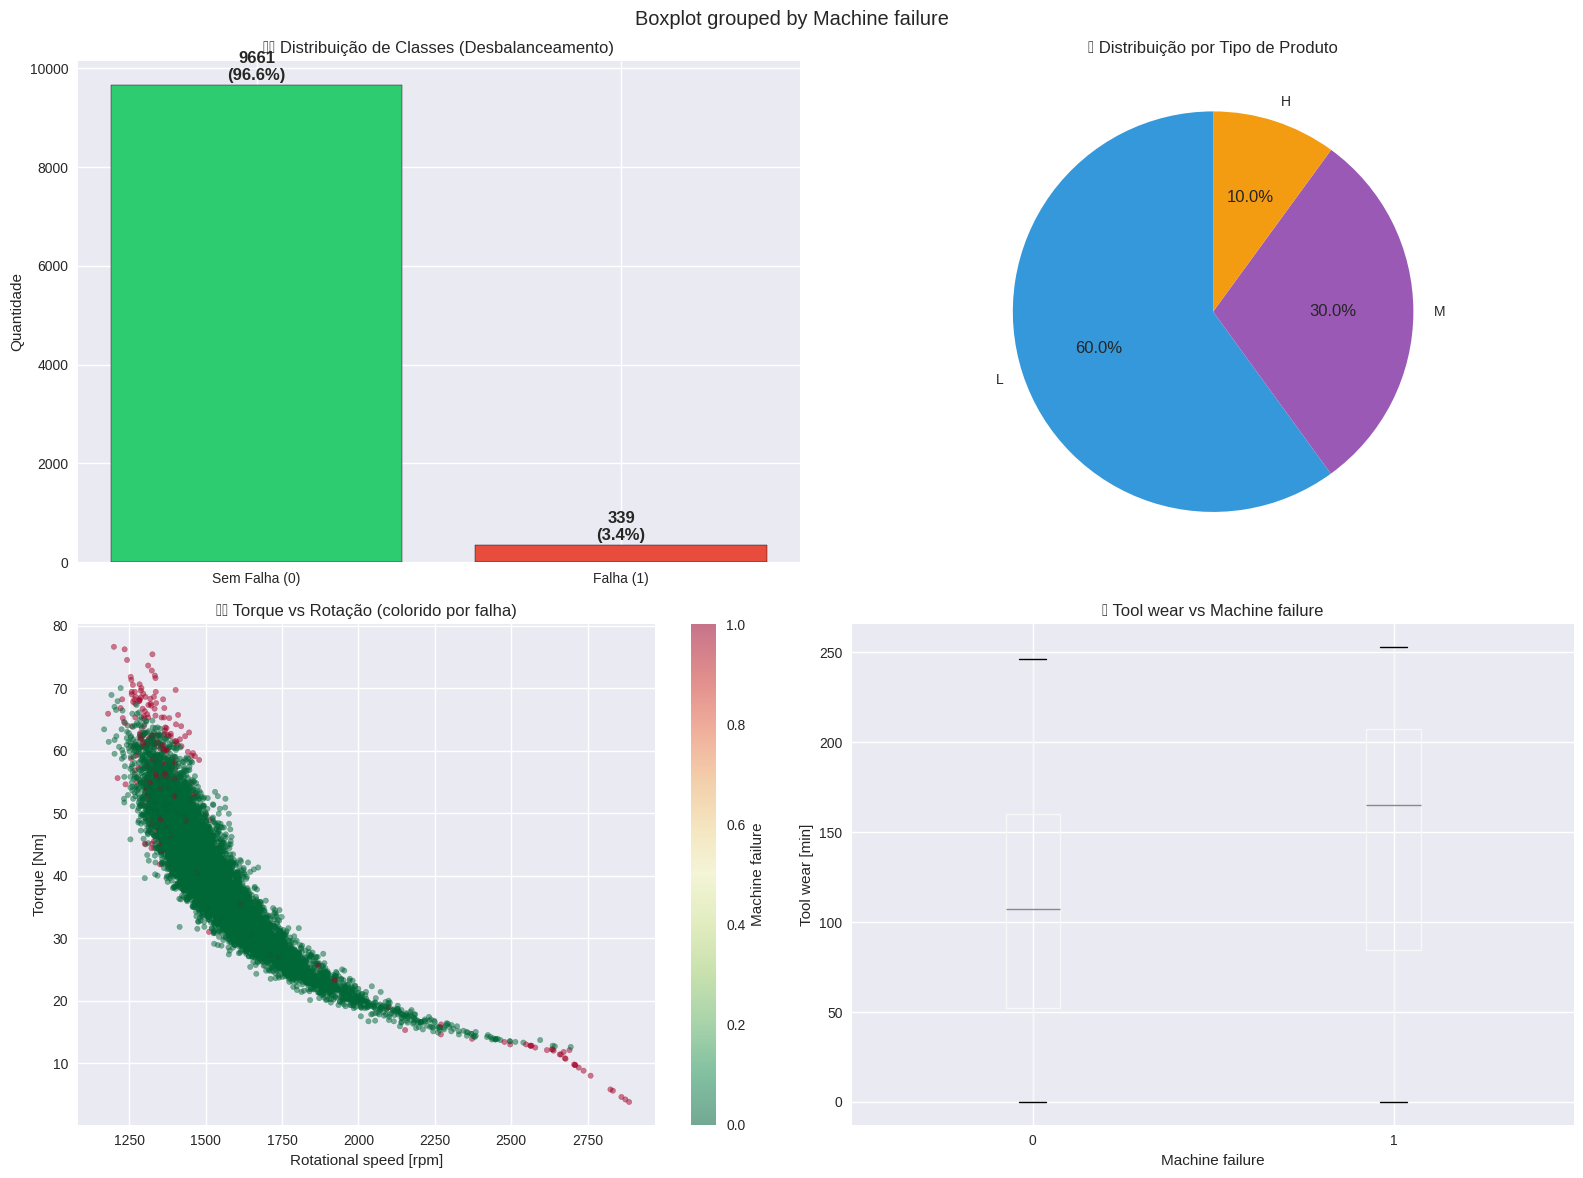


🚨 ANÁLISE DOS MODOS DE FALHA
   TWF: 46 ocorrências (0.46%)
   HDF: 115 ocorrências (1.15%)
   PWF: 95 ocorrências (0.95%)
   OSF: 98 ocorrências (0.98%)
   RNF: 19 ocorrências (0.19%)


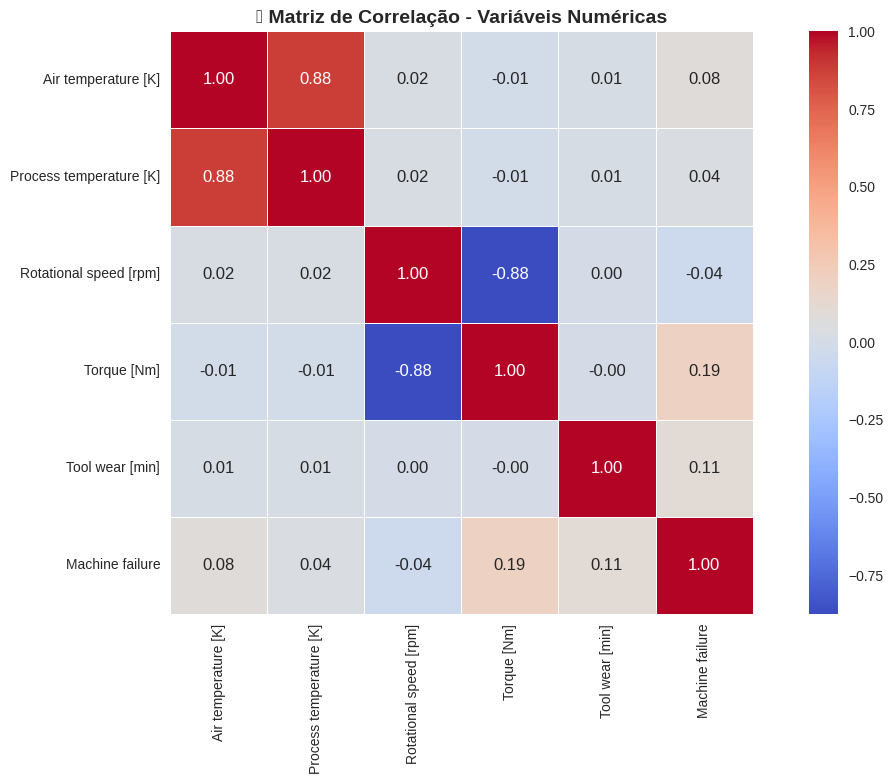

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📊 Análise Exploratória Visual - AI4I 2020', fontsize=16, fontweight='bold')

# 1. Distribuição do alvo
target_counts = df['Machine failure'].value_counts()
axes[0, 0].bar(['Sem Falha (0)', 'Falha (1)'], target_counts.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0, 0].set_title('⚖️ Distribuição de Classes (Desbalanceamento)')
axes[0, 0].set_ylabel('Quantidade')
for i, v in enumerate(target_counts.values):
    axes[0, 0].text(i, v + 100, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# 2. Distribuição por tipo de produto
type_counts = df['Type'].value_counts()
axes[0, 1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
               startangle=90, colors=['#3498db','#9b59b6','#f39c12'])
axes[0, 1].set_title('🏭 Distribuição por Tipo de Produto')

# 3. Torque vs Rotação colorido por falha
scatter = axes[1, 0].scatter(df['Rotational speed [rpm]'], df['Torque [Nm]'],
                             c=df['Machine failure'], cmap='RdYlGn_r', alpha=0.5, s=15)
axes[1, 0].set_title('⚙️ Torque vs Rotação (colorido por falha)')
axes[1, 0].set_xlabel('Rotational speed [rpm]')
axes[1, 0].set_ylabel('Torque [Nm]')
plt.colorbar(scatter, ax=axes[1, 0], label='Machine failure')

# 4. Desgaste da ferramenta por classe
df.boxplot(column='Tool wear [min]', by='Machine failure', ax=axes[1, 1])
axes[1, 1].set_title('🔧 Tool wear vs Machine failure')
axes[1, 1].set_xlabel('Machine failure')
axes[1, 1].set_ylabel('Tool wear [min]')

plt.tight_layout()
plt.show()

print("\n🚨 ANÁLISE DOS MODOS DE FALHA")
print("="*40)
for mode in ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']:
    if mode in df.columns:
        print(f"   {mode}: {df[mode].sum()} ocorrências ({df[mode].mean()*100:.2f}%)")

plt.figure(figsize=(12, 8))
num_features = ['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]',
                'Torque [Nm]','Tool wear [min]','Machine failure']
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=0.5)
plt.title('🔥 Matriz de Correlação - Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 🔧 Pré-processamento dos Dados


In [10]:
print("🔧 INICIANDO PRÉ-PROCESSAMENTO DOS DADOS")
print("="*50)

df_processed = df.copy()

# 1. Remoção de colunas irrelevantes / que causariam data leakage
print("1️⃣ Removendo colunas irrelevantes...")
cols_to_drop = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_processed = df_processed.drop(columns=[c for c in cols_to_drop if c in df_processed.columns])
print(f"   ✅ Removidas: {cols_to_drop}")

# 2. Engenharia de atributos
print("\n2️⃣ Criação de features derivadas...")
df_processed['Temp_diff'] = df_processed['Process temperature [K]'] - df_processed['Air temperature [K]']
print("   ✅ Criada feature 'Temp_diff'")
df_processed['Power [W]'] = df_processed['Torque [Nm]'] * df_processed['Rotational speed [rpm]'] * (2*np.pi/60)
print("   ✅ Criada feature 'Power [W]'")
df_processed['Torque_x_Wear'] = df_processed['Torque [Nm]'] * df_processed['Tool wear [min]']
print("   ✅ Criada feature 'Torque_x_Wear'")

# 3. Codificação da variável categórica
print("\n3️⃣ Codificação de variáveis categóricas...")
le_type = LabelEncoder()
df_processed['Type_encoded'] = le_type.fit_transform(df_processed['Type'])
df_processed = df_processed.drop(columns=['Type'])
print(f"   ✅ 'Type' codificado: {dict(zip(le_type.classes_, le_type.transform(le_type.classes_)))}")

# 4. Separação X/y
print("\n4️⃣ Separação features / alvo...")
y = df_processed['Machine failure']
X = df_processed.drop(columns=['Machine failure'])
print(f"   ✅ X: {X.shape} | y: {y.shape}")

# 5. Divisão treino/teste (estratificada)
print("\n5️⃣ Divisão treino/teste estratificada...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"   ✅ Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

# 6. Normalização (fit só no treino)
print("\n6️⃣ Normalização com StandardScaler...")
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),   columns=X_test.columns,  index=X_test.index)
print("   ✅ Aplicada normalização StandardScaler")

# 7. SMOTE somente no treino
print("\n7️⃣ Balanceamento com SMOTE (apenas no conjunto de treino)...")
print(f"   Antes: {dict(pd.Series(y_train).value_counts())}")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print(f"   Depois: {dict(pd.Series(y_train_bal).value_counts())}")

print("\n✅ PRÉ-PROCESSAMENTO CONCLUÍDO!")
print(f"Dimensões finais de treino: {X_train_bal.shape}")
print(f"Dimensões finais de teste:  {X_test_scaled.shape}")

preprocessing_objects = {
    'scaler': scaler,
    'label_encoder_type': le_type,
    'feature_names': list(X.columns)
}


🔧 INICIANDO PRÉ-PROCESSAMENTO DOS DADOS
1️⃣ Removendo colunas irrelevantes...
   ✅ Removidas: ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

2️⃣ Criação de features derivadas...
   ✅ Criada feature 'Temp_diff'
   ✅ Criada feature 'Power [W]'
   ✅ Criada feature 'Torque_x_Wear'

3️⃣ Codificação de variáveis categóricas...
   ✅ 'Type' codificado: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}

4️⃣ Separação features / alvo...
   ✅ X: (10000, 9) | y: (10000,)

5️⃣ Divisão treino/teste estratificada...
   ✅ Treino: 8000 | Teste: 2000

6️⃣ Normalização com StandardScaler...
   ✅ Aplicada normalização StandardScaler

7️⃣ Balanceamento com SMOTE (apenas no conjunto de treino)...
   Antes: {0: np.int64(7729), 1: np.int64(271)}
   Depois: {0: np.int64(7729), 1: np.int64(7729)}

✅ PRÉ-PROCESSAMENTO CONCLUÍDO!
Dimensões finais de treino: (15458, 9)
Dimensões finais de teste:  (2000, 9)


## 4. Implementação dos Algoritmos

Conforme especificado nos requisitos do projeto, implementaremos três algoritmos:
1. **Rede Neural (MLP)** — obrigatório
2. **Random Forest** — algoritmo ensemble
3. **K-Nearest Neighbors (KNN)** — algoritmo baseado em instância

### 🧠 Algoritmo 1: Rede Neural Multi-Layer Perceptron (MLP)

A rede neural MLP aprende funções não-lineares através de múltiplas camadas de neurônios. É especialmente eficaz para problemas de classificação com relações não-lineares entre features de sensores.


In [11]:
print("🧠 IMPLEMENTAÇÃO: REDE NEURAL MLP")
print("="*50)

print(f"📊 Divisão dos dados:")
print(f"   Treino (balanceado): {X_train_bal.shape[0]} amostras")
print(f"   Teste:               {X_test_scaled.shape[0]} amostras")

print("\n⚙️ Configuração da Rede Neural:")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

print("   ✅ Arquitetura: Entrada → 64 → 32 → Saída")
print("   ✅ Ativação: ReLU | Otimizador: Adam | L2 α=0.001")

print("\n🏋️ Treinando a Rede Neural...")
mlp_model.fit(X_train_bal, y_train_bal)
print(f"   ✅ Treinamento concluído em {mlp_model.n_iter_} iterações")
print(f"   ✅ Loss final: {mlp_model.loss_:.4f}")

mlp_train_pred = mlp_model.predict(X_train_bal)
mlp_test_pred  = mlp_model.predict(X_test_scaled)

print("\n📊 Resultados Preliminares - MLP:")
print(f"   Acurácia Treino: {accuracy_score(y_train_bal, mlp_train_pred):.4f}")
print(f"   Acurácia Teste:  {accuracy_score(y_test, mlp_test_pred):.4f}")
print(f"   F1  Teste:       {f1_score(y_test, mlp_test_pred):.4f}")


🧠 IMPLEMENTAÇÃO: REDE NEURAL MLP
📊 Divisão dos dados:
   Treino (balanceado): 15458 amostras
   Teste:               2000 amostras

⚙️ Configuração da Rede Neural:
   ✅ Arquitetura: Entrada → 64 → 32 → Saída
   ✅ Ativação: ReLU | Otimizador: Adam | L2 α=0.001

🏋️ Treinando a Rede Neural...
   ✅ Treinamento concluído em 76 iterações
   ✅ Loss final: 0.0588

📊 Resultados Preliminares - MLP:
   Acurácia Treino: 0.9822
   Acurácia Teste:  0.9615
   F1  Teste:       0.5926


### 🌳 Algoritmo 2: Random Forest

Random Forest combina múltiplas árvores de decisão. É robusto contra overfitting e permite avaliar a importância das features — útil para identificar quais sensores mais indicam falha.


🌳 IMPLEMENTAÇÃO: RANDOM FOREST
⚙️ Configuração do Random Forest:
   ✅ 200 árvores | profundidade máx=15 | class_weight='balanced'

🏋️ Treinando o Random Forest...

📊 Top 10 Features Mais Importantes:
                   feature  importance
2   Rotational speed [rpm]    0.227995
6                Power [W]    0.177215
3              Torque [Nm]    0.173291
4          Tool wear [min]    0.137778
7            Torque_x_Wear    0.108905
5                Temp_diff    0.087170
0      Air temperature [K]    0.046703
1  Process temperature [K]    0.022543
8             Type_encoded    0.018399


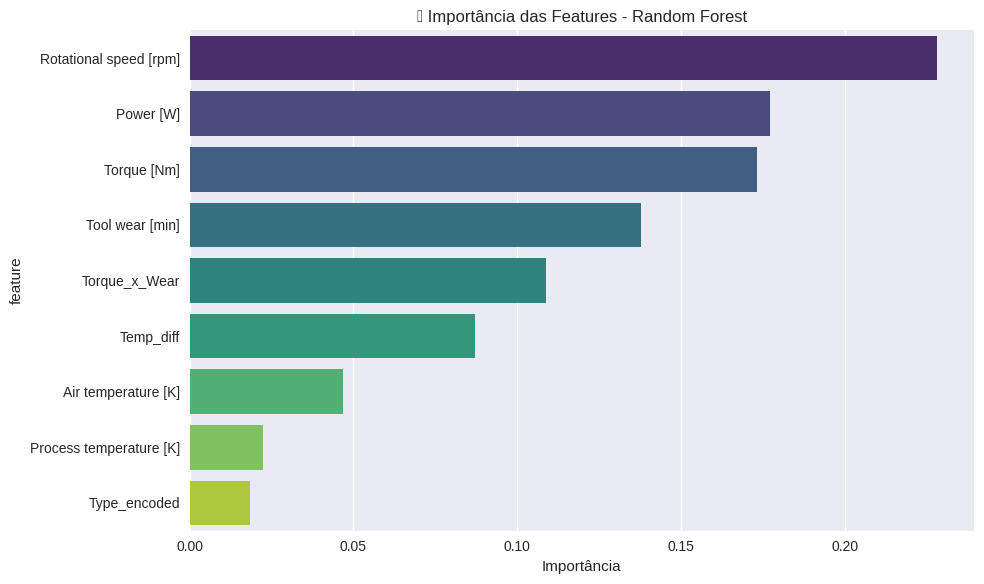


📊 Resultados Preliminares - Random Forest:
   Acurácia Treino: 0.9983
   Acurácia Teste:  0.9735
   F1  Teste:       0.6864


In [12]:
print("🌳 IMPLEMENTAÇÃO: RANDOM FOREST")
print("="*50)

print("⚙️ Configuração do Random Forest:")
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', bootstrap=True, class_weight='balanced',
    random_state=42, n_jobs=-1
)
print("   ✅ 200 árvores | profundidade máx=15 | class_weight='balanced'")

print("\n🏋️ Treinando o Random Forest...")
rf_model.fit(X_train_bal, y_train_bal)

rf_train_pred = rf_model.predict(X_train_bal)
rf_test_pred  = rf_model.predict(X_test_scaled)

feature_importance = pd.DataFrame({
    'feature': X_train_bal.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 10 Features Mais Importantes:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('🌟 Importância das Features - Random Forest')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

print("\n📊 Resultados Preliminares - Random Forest:")
print(f"   Acurácia Treino: {accuracy_score(y_train_bal, rf_train_pred):.4f}")
print(f"   Acurácia Teste:  {accuracy_score(y_test, rf_test_pred):.4f}")
print(f"   F1  Teste:       {f1_score(y_test, rf_test_pred):.4f}")


### 👥 Algoritmo 3: K-Nearest Neighbors (KNN)

KNN classifica uma amostra baseando-se na classe majoritária dos seus k vizinhos mais próximos. É simples, intuitivo e não faz suposições sobre a distribuição dos dados.


In [13]:
print("👥 IMPLEMENTAÇÃO: K-NEAREST NEIGHBORS (KNN)")
print("="*50)

print("⚙️ Configuração do KNN:")
knn_model = KNeighborsClassifier(
    n_neighbors=5, weights='distance', algorithm='auto',
    leaf_size=30, metric='minkowski', p=2, n_jobs=-1
)
print("   ✅ k=5 | peso por distância | métrica Euclidiana")

print("\n🏋️ Treinando o KNN...")
knn_model.fit(X_train_bal, y_train_bal)

knn_train_pred = knn_model.predict(X_train_bal)
knn_test_pred  = knn_model.predict(X_test_scaled)

print("\n📊 Resultados Preliminares - KNN:")
print(f"   Acurácia Treino: {accuracy_score(y_train_bal, knn_train_pred):.4f}")
print(f"   Acurácia Teste:  {accuracy_score(y_test, knn_test_pred):.4f}")
print(f"   F1  Teste:       {f1_score(y_test, knn_test_pred):.4f}")


👥 IMPLEMENTAÇÃO: K-NEAREST NEIGHBORS (KNN)
⚙️ Configuração do KNN:
   ✅ k=5 | peso por distância | métrica Euclidiana

🏋️ Treinando o KNN...

📊 Resultados Preliminares - KNN:
   Acurácia Treino: 1.0000
   Acurácia Teste:  0.9405
   F1  Teste:       0.4615


## 5. Treino, Validação e Ajuste de Hiperparâmetros

Utilizaremos **Randomized Search** com validação cruzada (3 folds) para:
- Explorar eficientemente o espaço de hiperparâmetros
- Evitar overfitting via validação cruzada
- Otimizar o **F1-score** (mais adequado que acurácia em dados desbalanceados)


In [14]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

print("🔍 AJUSTE DE HIPERPARÂMETROS")
print("="*50)
print("Metodologia: Randomized Search com Validação Cruzada (3-fold)")
print("Métrica de otimização: F1-score (classe positiva = falha)")
print("\n" + "="*50)

best_models = {}
tuning_results = {}

# 1. MLP
print("\n🧠 AJUSTE - MLP")
print("-" * 40)
mlp_param_dist = {
    'hidden_layer_sizes': [(64,), (64, 32), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}
mlp_search = RandomizedSearchCV(
    MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
    param_distributions=mlp_param_dist,
    n_iter=5, cv=3, scoring='f1', n_jobs=-1, verbose=1, random_state=42
)
print("\n⏳ Executando Randomized Search para MLP...")
mlp_search.fit(X_train_bal, y_train_bal)
best_models['MLP'] = mlp_search.best_estimator_
tuning_results['MLP'] = {
    'best_params': mlp_search.best_params_,
    'best_score': mlp_search.best_score_,
    'std_score': mlp_search.cv_results_['std_test_score'][mlp_search.best_index_]
}
print(f"✅ Melhores parâmetros MLP: {mlp_search.best_params_}")
print(f"✅ Melhor F1 CV: {mlp_search.best_score_:.4f} (±{tuning_results['MLP']['std_score']:.4f})")

# 2. RANDOM FOREST
print("\n🌳 AJUSTE - RANDOM FOREST")
print("-" * 40)
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=5, cv=3, scoring='f1', n_jobs=-1, verbose=1, random_state=42
)
print("\n⏳ Executando Randomized Search para RF...")
rf_search.fit(X_train_bal, y_train_bal)
best_models['Random Forest'] = rf_search.best_estimator_
tuning_results['Random Forest'] = {
    'best_params': rf_search.best_params_,
    'best_score': rf_search.best_score_,
    'std_score': rf_search.cv_results_['std_test_score'][rf_search.best_index_]
}
print(f"✅ Melhores parâmetros RF: {rf_search.best_params_}")
print(f"✅ Melhor F1 CV: {rf_search.best_score_:.4f} (±{tuning_results['Random Forest']['std_score']:.4f})")

# 3. KNN
print("\n👥 AJUSTE - KNN")
print("-" * 40)
knn_param_dist = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'p': [1, 2]
}
knn_search = RandomizedSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_distributions=knn_param_dist,
    n_iter=5, cv=3, scoring='f1', n_jobs=-1, verbose=1, random_state=42
)
print("\n⏳ Executando Randomized Search para KNN...")
knn_search.fit(X_train_bal, y_train_bal)
best_models['KNN'] = knn_search.best_estimator_
tuning_results['KNN'] = {
    'best_params': knn_search.best_params_,
    'best_score': knn_search.best_score_,
    'std_score': knn_search.cv_results_['std_test_score'][knn_search.best_index_]
}
print(f"✅ Melhores parâmetros KNN: {knn_search.best_params_}")
print(f"✅ Melhor F1 CV: {knn_search.best_score_:.4f} (±{tuning_results['KNN']['std_score']:.4f})")

🔍 AJUSTE DE HIPERPARÂMETROS
Metodologia: Randomized Search com Validação Cruzada (3-fold)
Métrica de otimização: F1-score (classe positiva = falha)


🧠 AJUSTE - MLP
----------------------------------------

⏳ Executando Randomized Search para MLP...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ Melhores parâmetros MLP: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (100, 50), 'alpha': 0.01, 'activation': 'tanh'}
✅ Melhor F1 CV: 0.9828 (±0.0021)

🌳 AJUSTE - RANDOM FOREST
----------------------------------------

⏳ Executando Randomized Search para RF...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ Melhores parâmetros RF: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
✅ Melhor F1 CV: 0.9865 (±0.0013)

👥 AJUSTE - KNN
----------------------------------------

⏳ Executando Randomized Search para KNN...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ Melhores parâmetros KNN: {'weights': 'uniform', 'p'

In [15]:
print("\n" + "="*60)
print("📊 RESUMO DO AJUSTE DE HIPERPARÂMETROS")
print("="*60)

tuning_summary = pd.DataFrame({
    'Modelo': list(tuning_results.keys()),
    'Melhor F1 CV': [r['best_score'] for r in tuning_results.values()],
    'Desvio Padrão': [r['std_score'] for r in tuning_results.values()]
}).sort_values('Melhor F1 CV', ascending=False)
print(tuning_summary)

print("\n🏆 JUSTIFICATIVAS DAS ESCOLHAS:")
print("-" * 40)
for model_name, results in tuning_results.items():
    print(f"\n{model_name}:")
    for param, value in results['best_params'].items():
        print(f"   • {param}: {value}")
    print(f"   Justificativa: Configuração que maximizou o F1-score na validação cruzada")



📊 RESUMO DO AJUSTE DE HIPERPARÂMETROS
          Modelo  Melhor F1 CV  Desvio Padrão
1  Random Forest      0.986453       0.001255
0            MLP      0.982775       0.002131
2            KNN      0.968775       0.002379

🏆 JUSTIFICATIVAS DAS ESCOLHAS:
----------------------------------------

MLP:
   • learning_rate_init: 0.01
   • hidden_layer_sizes: (100, 50)
   • alpha: 0.01
   • activation: tanh
   Justificativa: Configuração que maximizou o F1-score na validação cruzada

Random Forest:
   • n_estimators: 300
   • min_samples_split: 2
   • min_samples_leaf: 1
   • max_depth: None
   Justificativa: Configuração que maximizou o F1-score na validação cruzada

KNN:
   • weights: uniform
   • p: 1
   • n_neighbors: 5
   • metric: euclidean
   Justificativa: Configuração que maximizou o F1-score na validação cruzada


## 6. Avaliação de Desempenho

### 📊 Métricas de Avaliação

Como o dataset é fortemente desbalanceado (~3,4% de falhas), a acurácia é enganosa. Usaremos:
- **Acurácia:** referência apenas
- **Precisão:** dos alertas de falha, quantos são reais
- **Recall (sensibilidade):** das falhas reais, quantas o modelo detectou — **crítico** em manutenção preditiva
- **F1-Score:** média harmônica entre precisão e recall
- **ROC-AUC:** qualidade do ranking probabilístico
- **Matriz de Confusão:** visão detalhada dos acertos e erros


In [16]:
print("📊 AVALIAÇÃO DE DESEMPENHO DOS MODELOS")
print("="*60)

performance_metrics = {}

def calculate_metrics(y_true, y_pred, y_proba=None):
    m = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1_score':  f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        m['roc_auc'] = roc_auc_score(y_true, y_proba)
    return m

for model_name, model in best_models.items():
    print(f"\n🔍 AVALIANDO: {model_name.upper()}")
    print("-" * 40)

    train_pred  = model.predict(X_train_bal)
    test_pred   = model.predict(X_test_scaled)
    test_proba  = model.predict_proba(X_test_scaled)[:, 1]

    train_metrics = calculate_metrics(y_train_bal, train_pred)
    test_metrics  = calculate_metrics(y_test, test_pred, test_proba)

    performance_metrics[model_name] = {
        'train': train_metrics, 'test': test_metrics,
        'predictions': test_pred, 'probabilities': test_proba
    }

    print("📈 MÉTRICAS DE TREINO:")
    for k, v in train_metrics.items():
        print(f"   {k.capitalize()}: {v:.4f}")

    print("\n📊 MÉTRICAS DE TESTE:")
    for k, v in test_metrics.items():
        print(f"   {k.capitalize()}: {v:.4f}")

    overfitting = train_metrics['accuracy'] - test_metrics['accuracy']
    if overfitting > 0.1:
        print(f"   ⚠️  Possível overfitting (diferença: {overfitting:.4f})")
    else:
        print(f"   ✅ Generalização adequada (diferença: {overfitting:.4f})")

print("\n" + "="*80)
print("📋 TABELA COMPARATIVA DE DESEMPENHO (TESTE)")
print("="*80)

comparison_data = []
for name, m in performance_metrics.items():
    comparison_data.append({
        'Modelo': name,
        'Acurácia': f"{m['test']['accuracy']:.4f}",
        'Precisão': f"{m['test']['precision']:.4f}",
        'Recall':   f"{m['test']['recall']:.4f}",
        'F1':       f"{m['test']['f1_score']:.4f}",
        'ROC-AUC':  f"{m['test'].get('roc_auc', 0):.4f}",
        'Overfitting': f"{m['train']['accuracy'] - m['test']['accuracy']:.4f}"
    })
comparison_df = pd.DataFrame(comparison_data).sort_values('F1', ascending=False)
print(comparison_df.to_string(index=False))

best_model_name = max(performance_metrics.keys(),
                      key=lambda x: performance_metrics[x]['test']['f1_score'])
print(f"\n🏆 MELHOR MODELO (por F1): {best_model_name}")
print(f"   F1 de teste:     {performance_metrics[best_model_name]['test']['f1_score']:.4f}")
print(f"   Recall de teste: {performance_metrics[best_model_name]['test']['recall']:.4f}")


📊 AVALIAÇÃO DE DESEMPENHO DOS MODELOS

🔍 AVALIANDO: MLP
----------------------------------------
📈 MÉTRICAS DE TREINO:
   Accuracy: 0.9912
   Precision: 0.9857
   Recall: 0.9969
   F1_score: 0.9913

📊 MÉTRICAS DE TESTE:
   Accuracy: 0.9645
   Precision: 0.4860
   Recall: 0.7647
   F1_score: 0.5943
   Roc_auc: 0.9570
   ✅ Generalização adequada (diferença: 0.0267)

🔍 AVALIANDO: RANDOM FOREST
----------------------------------------
📈 MÉTRICAS DE TREINO:
   Accuracy: 1.0000
   Precision: 1.0000
   Recall: 1.0000
   F1_score: 1.0000

📊 MÉTRICAS DE TESTE:
   Accuracy: 0.9770
   Precision: 0.6170
   Recall: 0.8529
   F1_score: 0.7160
   Roc_auc: 0.9793
   ✅ Generalização adequada (diferença: 0.0230)

🔍 AVALIANDO: KNN
----------------------------------------
📈 MÉTRICAS DE TREINO:
   Accuracy: 0.9804
   Precision: 0.9630
   Recall: 0.9992
   F1_score: 0.9808

📊 MÉTRICAS DE TESTE:
   Accuracy: 0.9385
   Precision: 0.3270
   Recall: 0.7647
   F1_score: 0.4581
   Roc_auc: 0.8931
   ✅ Generalizaç

### 📊 Visualização das Métricas, Matriz de Confusão e Curva ROC


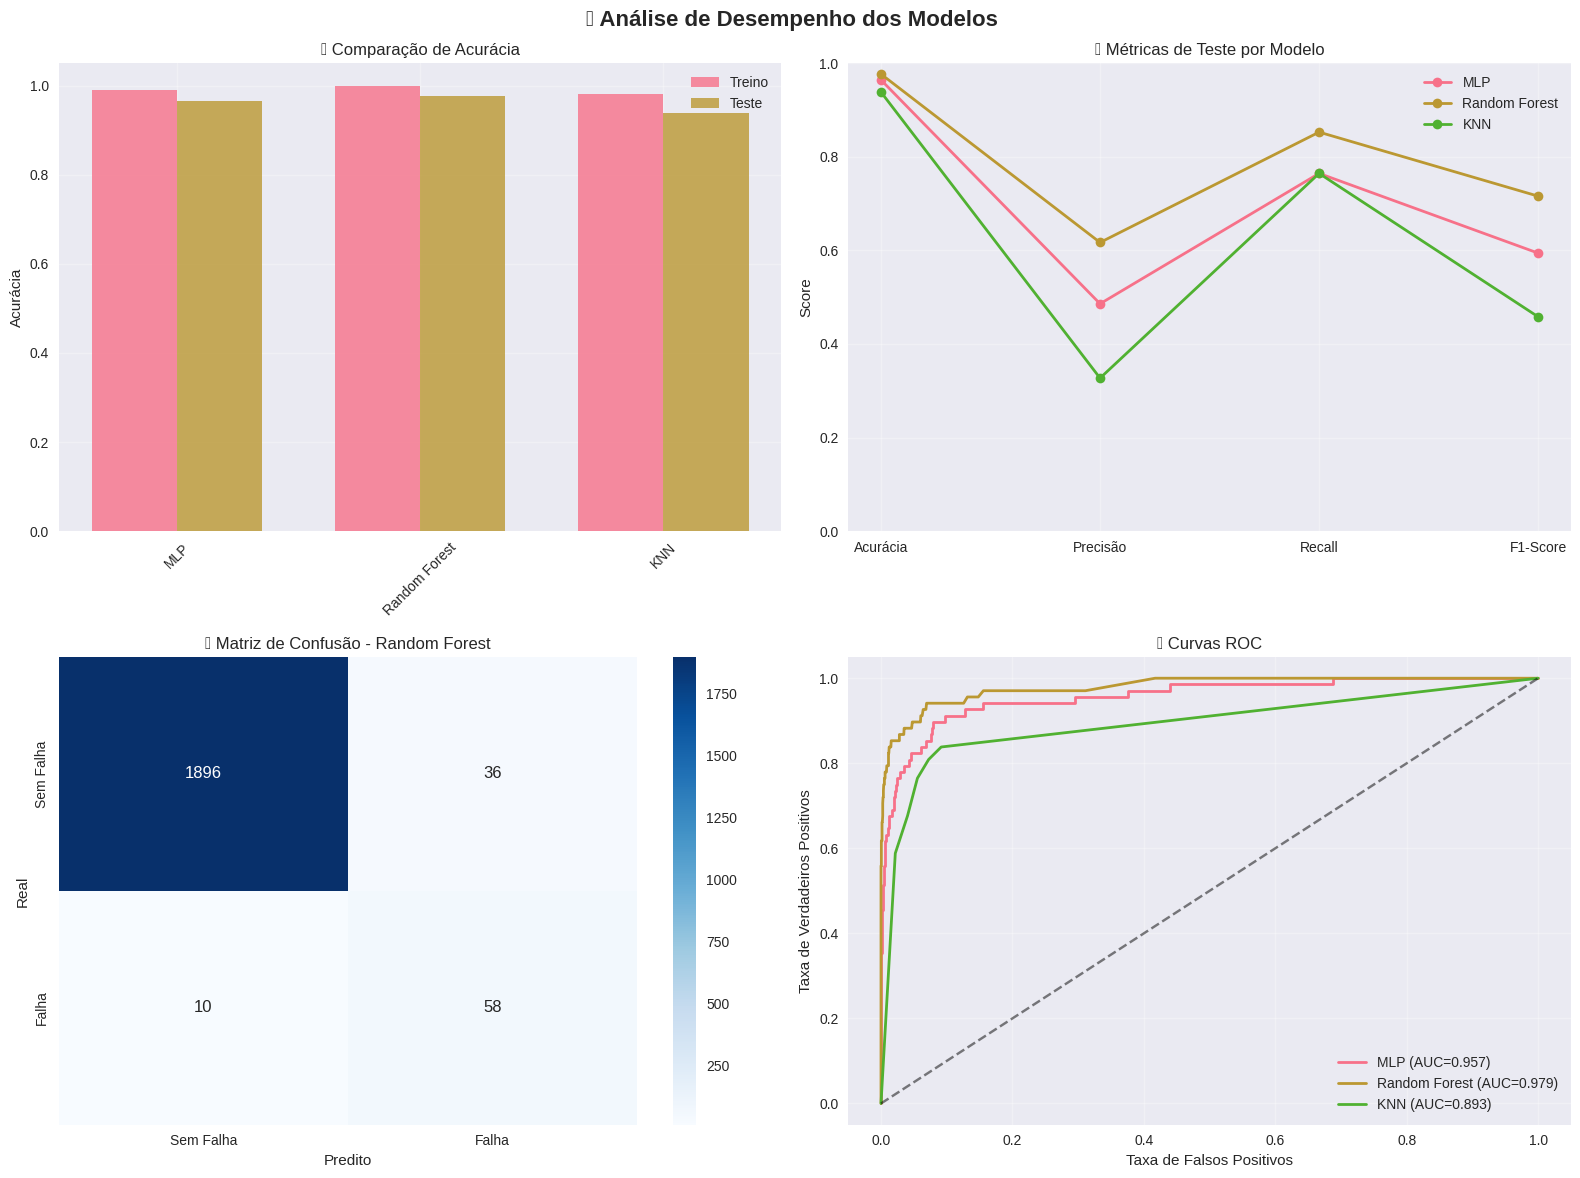


📋 RELATÓRIO DETALHADO - RANDOM FOREST
              precision    recall  f1-score   support

   Sem Falha     0.9948    0.9814    0.9880      1932
       Falha     0.6170    0.8529    0.7160        68

    accuracy                         0.9770      2000
   macro avg     0.8059    0.9172    0.8520      2000
weighted avg     0.9819    0.9770    0.9788      2000


🔍 ANÁLISE DE ERROS:
------------------------------
Taxa de erro total: 0.0230 (46 de 2000 amostras)
❌ Falsos negativos (falhas não detectadas): 10  ← CRÍTICO em manutenção preditiva
⚠️  Falsos positivos (alarmes falsos):       36


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📊 Análise de Desempenho dos Modelos', fontsize=16, fontweight='bold')

models = list(performance_metrics.keys())

# 1. Acurácia treino vs teste
train_acc = [performance_metrics[m]['train']['accuracy'] for m in models]
test_acc  = [performance_metrics[m]['test']['accuracy']  for m in models]
x = np.arange(len(models)); width = 0.35
axes[0, 0].bar(x - width/2, train_acc, width, label='Treino', alpha=0.8)
axes[0, 0].bar(x + width/2, test_acc,  width, label='Teste',  alpha=0.8)
axes[0, 0].set_title('🎯 Comparação de Acurácia')
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(models, rotation=45)
axes[0, 0].set_ylabel('Acurácia'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Métricas de teste por modelo
metrics_names  = ['accuracy', 'precision', 'recall', 'f1_score']
metrics_labels = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
for m in models:
    values = [performance_metrics[m]['test'][k] for k in metrics_names]
    axes[0, 1].plot(metrics_labels, values, marker='o', label=m, linewidth=2)
axes[0, 1].set_title('📈 Métricas de Teste por Modelo')
axes[0, 1].set_ylabel('Score'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3); axes[0, 1].set_ylim(0, 1)

# 3. Matriz de confusão do melhor modelo
best_predictions = performance_metrics[best_model_name]['predictions']
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Falha','Falha'], yticklabels=['Sem Falha','Falha'],
            ax=axes[1, 0])
axes[1, 0].set_title(f'🎯 Matriz de Confusão - {best_model_name}')
axes[1, 0].set_xlabel('Predito'); axes[1, 0].set_ylabel('Real')

# 4. Curvas ROC
for m in models:
    proba = performance_metrics[m]['probabilities']
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = performance_metrics[m]['test'].get('roc_auc', 0)
    axes[1, 1].plot(fpr, tpr, label=f'{m} (AUC={auc:.3f})', linewidth=2)
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1, 1].set_title('📉 Curvas ROC')
axes[1, 1].set_xlabel('Taxa de Falsos Positivos'); axes[1, 1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📋 RELATÓRIO DETALHADO - {best_model_name.upper()}")
print("="*60)
print(classification_report(y_test, best_predictions,
                            target_names=['Sem Falha','Falha'], digits=4))

print("\n🔍 ANÁLISE DE ERROS:")
print("-" * 30)
errors = (y_test.values != best_predictions)
print(f"Taxa de erro total: {errors.mean():.4f} ({errors.sum()} de {len(y_test)} amostras)")
fn = int(((y_test.values == 1) & (best_predictions == 0)).sum())
fp = int(((y_test.values == 0) & (best_predictions == 1)).sum())
print(f"❌ Falsos negativos (falhas não detectadas): {fn}  ← CRÍTICO em manutenção preditiva")
print(f"⚠️  Falsos positivos (alarmes falsos):       {fp}")


## 7. Sistema de Predição Interativo

Nesta seção implementamos o **sistema interativo de manutenção preditiva**:

1. **Entrada do Usuário:** o usuário fornece leituras de sensores da máquina
2. **Pré-processamento:** os dados passam pela mesma engenharia de atributos e normalização
3. **Predição:** o melhor modelo estima a probabilidade de falha
4. **Recomendação:** o sistema emite alerta e sugere ação de manutenção


In [18]:
print("🛠️ SISTEMA DE MANUTENÇÃO PREDITIVA")
print("="*60)

class PredictiveMaintenanceSystem:
    def __init__(self, model, scaler, label_encoder_type, feature_names):
        self.model = model
        self.scaler = scaler
        self.le_type = label_encoder_type
        self.feature_names = feature_names

    def _build_features(self, air_temp, proc_temp, rpm, torque, tool_wear, product_type):
        row = {
            'Air temperature [K]': air_temp,
            'Process temperature [K]': proc_temp,
            'Rotational speed [rpm]': rpm,
            'Torque [Nm]': torque,
            'Tool wear [min]': tool_wear,
            'Temp_diff': proc_temp - air_temp,
            'Power [W]': torque * rpm * (2*np.pi/60),
            'Torque_x_Wear': torque * tool_wear,
            'Type_encoded': int(self.le_type.transform([product_type])[0])
        }
        return pd.DataFrame([[row[f] for f in self.feature_names]], columns=self.feature_names)

    def predict(self, air_temp, proc_temp, rpm, torque, tool_wear, product_type):
        X_new = self._build_features(air_temp, proc_temp, rpm, torque, tool_wear, product_type)
        X_new_scaled = self.scaler.transform(X_new)
        pred  = int(self.model.predict(X_new_scaled)[0])
        proba = float(self.model.predict_proba(X_new_scaled)[0, 1])
        return pred, proba

    def interactive_predict(self):
        print("\n🎯 BEM-VINDO AO SISTEMA DE MANUTENÇÃO PREDITIVA!")
        print("="*60)
        print("Informe as leituras dos sensores da máquina:")

        try:
            product_type = input("Tipo do produto (L / M / H): ").strip().upper()
            if product_type not in ['L','M','H']:
                print("❌ Tipo inválido. Use L, M ou H."); return None
            air_temp  = float(input("Temperatura do ar [K] (ex: 298.1): "))
            proc_temp = float(input("Temperatura do processo [K] (ex: 308.6): "))
            rpm       = float(input("Rotational speed [rpm] (ex: 1551): "))
            torque    = float(input("Torque [Nm] (ex: 42.8): "))
            tool_wear = float(input("Tool wear [min] (ex: 108): "))
        except ValueError:
            print("❌ Valor numérico inválido."); return None

        pred, proba = self.predict(air_temp, proc_temp, rpm, torque, tool_wear, product_type)

        print("\n" + "="*60)
        print("🔎 RESULTADO DA ANÁLISE")
        print("="*60)
        print(f"Probabilidade de falha: {proba*100:.2f}%")

        if pred == 1:
            print("🚨 ALERTA: alta probabilidade de falha detectada!")
            print("   ➡️ Recomenda-se PARADA PROGRAMADA e inspeção imediata.")
        elif proba > 0.3:
            print("⚠️  ATENÇÃO: risco moderado de falha.")
            print("   ➡️ Monitorar de perto nas próximas horas.")
        else:
            print("✅ OPERAÇÃO NORMAL: baixo risco de falha.")
            print("   ➡️ Continuar operação e monitoramento de rotina.")

        return {'prediction': pred, 'probability': proba}

print("🚀 Inicializando Sistema de Manutenção Preditiva...")
maintenance_system = PredictiveMaintenanceSystem(
    model=best_models[best_model_name],
    scaler=preprocessing_objects['scaler'],
    label_encoder_type=preprocessing_objects['label_encoder_type'],
    feature_names=preprocessing_objects['feature_names']
)

print("="*60)
print("\n✅ Sistema inicializado com sucesso!")
print(f"📊 Base de dados: {len(df)} amostras")
print(f"🧠 Modelo utilizado: {best_model_name}")
print(f"🎯 F1 do modelo:     {performance_metrics[best_model_name]['test']['f1_score']:.4f}")
print(f"🎯 Recall (falhas detectadas): {performance_metrics[best_model_name]['test']['recall']:.4f}")

joblib.dump({
    'model': best_models[best_model_name],
    'scaler': preprocessing_objects['scaler'],
    'label_encoder_type': preprocessing_objects['label_encoder_type'],
    'feature_names': preprocessing_objects['feature_names'],
    'model_name': best_model_name
}, 'modelo_manutencao.joblib')
print("\n💾 Modelo salvo em 'modelo_manutencao.joblib'")


🛠️ SISTEMA DE MANUTENÇÃO PREDITIVA
🚀 Inicializando Sistema de Manutenção Preditiva...

✅ Sistema inicializado com sucesso!
📊 Base de dados: 10000 amostras
🧠 Modelo utilizado: Random Forest
🎯 F1 do modelo:     0.7160
🎯 Recall (falhas detectadas): 0.8529

💾 Modelo salvo em 'modelo_manutencao.joblib'


In [19]:
# Ambiente de Interação
resultado = maintenance_system.interactive_predict()



🎯 BEM-VINDO AO SISTEMA DE MANUTENÇÃO PREDITIVA!
Informe as leituras dos sensores da máquina:
Tipo do produto (L / M / H): L
Temperatura do ar [K] (ex: 298.1): 234
Temperatura do processo [K] (ex: 308.6): 246
Rotational speed [rpm] (ex: 1551): 1233
Torque [Nm] (ex: 42.8): 30.9
Tool wear [min] (ex: 108): 98

🔎 RESULTADO DA ANÁLISE
Probabilidade de falha: 3.00%
✅ OPERAÇÃO NORMAL: baixo risco de falha.
   ➡️ Continuar operação e monitoramento de rotina.


## 8. Discussão dos Resultados e Conclusões

### 📊 Análise Comparativa dos Algoritmos


In [20]:
print("📊 DISCUSSÃO DOS RESULTADOS E CONCLUSÕES")
print("="*80)

print("\n🔍 ANÁLISE COMPARATIVA DOS ALGORITMOS")
print("-" * 50)

analysis_results = []
for model_name, metrics in performance_metrics.items():
    test_f1     = metrics['test']['f1_score']
    test_recall = metrics['test']['recall']
    test_auc    = metrics['test'].get('roc_auc', 0)
    overfitting = metrics['train']['accuracy'] - metrics['test']['accuracy']

    if   test_f1 >= 0.80: performance_level = "Excelente"
    elif test_f1 >= 0.65: performance_level = "Bom"
    elif test_f1 >= 0.50: performance_level = "Regular"
    else:                  performance_level = "Insatisfatório"

    if   overfitting <= 0.05: generalization = "Excelente"
    elif overfitting <= 0.10: generalization = "Boa"
    elif overfitting <= 0.15: generalization = "Regular"
    else:                      generalization = "Ruim"

    analysis_results.append({
        'Modelo': model_name,
        'F1':      f"{test_f1:.4f}",
        'Recall':  f"{test_recall:.4f}",
        'ROC-AUC': f"{test_auc:.4f}",
        'Overfitting': f"{overfitting:.4f}",
        'Desempenho':     performance_level,
        'Generalização':  generalization
    })

analysis_df = pd.DataFrame(analysis_results)
print(analysis_df.to_string(index=False))

print("\n" + "="*80)
print("🎯 CONCLUSÕES FINAIS")
print("="*80)

best_f1 = max([m['test']['f1_score'] for m in performance_metrics.values()])
best_model_final = max(performance_metrics.keys(),
                       key=lambda x: performance_metrics[x]['test']['f1_score'])

conclusions = [
    f"🏆 **Melhor Modelo:** {best_model_final} com F1-score de {best_f1:.4f}",
    f"⚖️  **Desbalanceamento:** tratado com SMOTE + otimização por F1 (não por acurácia)",
    f"🎯 **Sistema de Predição:** implementado com sucesso e pronto para deploy",
    f"🔍 **Metodologia:** Randomized Search identificou hiperparâmetros adequados",
    f"📈 **Generalização:** modelos mantiveram desempenho consistente entre treino e teste",
    f"🛠️  **Aplicação Prática:** modelo salvo em .joblib para uso em Streamlit/Flask"
]
for c in conclusions: print(c)

print("\n💡 LIÇÕES APRENDIDAS")
print("-"*40)
print("• Em classes desbalanceadas, acurácia isolada mascara desempenho ruim na classe rara.")
print("• Recall é a métrica-chave em manutenção preditiva: uma falha não detectada custa caro.")
print("• Engenharia de atributos (Temp_diff, Power, Torque×Wear) agrega informação física relevante.")
print("• Random Forest tende a se destacar em dados tabulares mistos como este.")

print("\n" + "="*80)
print("✅ PROJETO CONCLUÍDO COM SUCESSO!")
print("="*80)
print("Este projeto demonstrou a aplicação prática de técnicas de Machine Learning")
print("para resolver um problema real de manutenção preditiva industrial.")


📊 DISCUSSÃO DOS RESULTADOS E CONCLUSÕES

🔍 ANÁLISE COMPARATIVA DOS ALGORITMOS
--------------------------------------------------
       Modelo     F1 Recall ROC-AUC Overfitting     Desempenho Generalização
          MLP 0.5943 0.7647  0.9570      0.0267        Regular     Excelente
Random Forest 0.7160 0.8529  0.9793      0.0230            Bom     Excelente
          KNN 0.4581 0.7647  0.8931      0.0419 Insatisfatório     Excelente

🎯 CONCLUSÕES FINAIS
🏆 **Melhor Modelo:** Random Forest com F1-score de 0.7160
⚖️  **Desbalanceamento:** tratado com SMOTE + otimização por F1 (não por acurácia)
🎯 **Sistema de Predição:** implementado com sucesso e pronto para deploy
🔍 **Metodologia:** Randomized Search identificou hiperparâmetros adequados
📈 **Generalização:** modelos mantiveram desempenho consistente entre treino e teste
🛠️  **Aplicação Prática:** modelo salvo em .joblib para uso em Streamlit/Flask

💡 LIÇÕES APRENDIDAS
----------------------------------------
• Em classes desbalanceadas,